# Module 4 - Session 5: Practical Exercises

Objective: Implement PCA with scikit-learn to project a high-dimensional dataset (Iris) into 2D and visualize class separation.

## Exercise 1 - PCA for Visualization (Coding)
We'll load the classic Iris dataset (4 features), standardize the features, reduce them to two principal components, and plot them colored by the species labels.

In [5]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

plt.style.use('seaborn-v0_8')


In [6]:
# Load data and standardize features (PCA is scale-sensitive)
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [7]:
# Fit PCA to get 2 principal components
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(principal_components, columns=["PC1", "PC2"])

pca_df.head()

,PC1,PC2
0,-2.264703,0.480027
1,-2.080961,-0.674134
2,-2.364229,-0.341908
3,-2.299384,-0.597395
4,-2.389842,0.646835


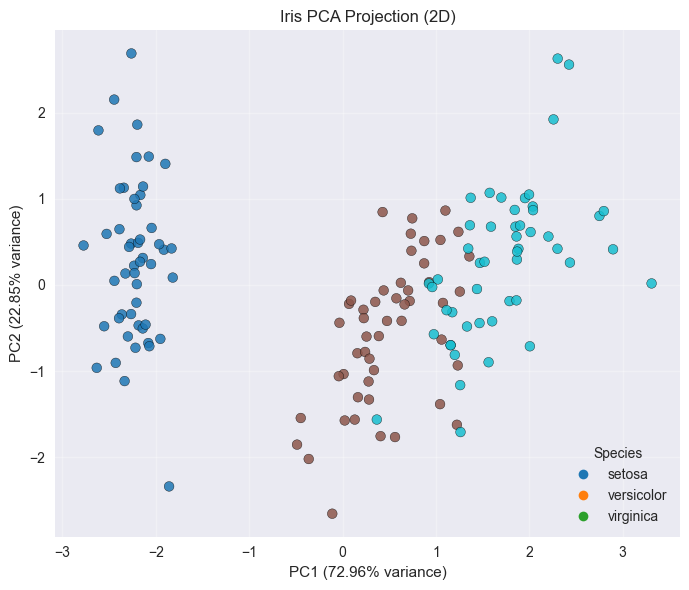

In [8]:
# Scatter plot of the PCA projection colored by species
plt.figure(figsize=(7, 6))
palette = plt.cm.tab10.colors
plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=y,
    cmap="tab10",
    edgecolor="k",
    alpha=0.85,
)

handles = [
    plt.Line2D(
        [], [],
        marker='o', linestyle='',
        markerfacecolor=palette[i], markeredgecolor='k',
        label=iris.target_names[i]
    )
    for i in range(len(iris.target_names))
]
plt.legend(handles=handles, title="Species", loc="best")
plt.title("Iris PCA Projection (2D)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**PCA separation:** The 2D projection cleanly separates setosa. Versicolor and virginica overlap slightly but still form mostly distinct regions, so PCA captures most class structure even though those two classes are not perfectly linearly separable in two dimensions.